In [46]:
import pystac_client
import planetary_computer as pc
import rioxarray
import xarray as xr
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt
import pandas as pd

In [47]:
### Define the AOI

# Same AOI as Notebook 01 (San Francisco)
aoi = box(-122.50, 37.75, -122.40, 37.85)
gdf = gpd.GeoDataFrame({"geometry": [aoi]}, crs="EPSG:4326")
gdf.explore()

In [48]:
### Search STAC for multiple dates

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1"
)

search = catalog.search(
    collections=["sentinel-2-l2a"],
    intersects=gdf.geometry.iloc[0],
    datetime="2023-01-01/2023-12-31",
    query={"eo:cloud_cover": {"lt": 60}},  # allow more, we'll pick best per month
)

items = list(search.get_items())
len(items)



C:\Users\snd21\anaconda3\Lib\site-packages\pystac_client\item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


84

In [49]:
### Keep only the least cloudy scene per month

monthly = {}
for item in items:
    month = item.datetime.month
    cc = item.properties.get("eo:cloud_cover", 100)
    if month not in monthly or cc < monthly[month].properties.get("eo:cloud_cover", 100):
        monthly[month] = item

items_monthly = sorted(monthly.values(), key=lambda x: x.datetime)
len(items_monthly), [i.datetime.date() for i in items_monthly]

(12,
 [datetime.date(2023, 1, 24),
  datetime.date(2023, 2, 8),
  datetime.date(2023, 3, 25),
  datetime.date(2023, 4, 19),
  datetime.date(2023, 5, 9),
  datetime.date(2023, 6, 18),
  datetime.date(2023, 7, 13),
  datetime.date(2023, 8, 22),
  datetime.date(2023, 9, 21),
  datetime.date(2023, 10, 6),
  datetime.date(2023, 11, 20),
  datetime.date(2023, 12, 30)])

In [50]:
### Define helper functions

def compute_ndvi(red, nir):
    return (nir - red) / (nir + red)


In [51]:
### Reproject AOI

# Use first monthly item to get CRS
sample_item = pc.sign(items_monthly[0])
sample_red = rioxarray.open_rasterio(
    sample_item.assets["B05"].href  # 20m red-edge as proxy "red"
).squeeze()

gdf_utm = gdf.to_crs(sample_red.rio.crs)
minx, miny, maxx, maxy = gdf_utm.total_bounds


In [52]:
### Time-Series Loop

ndvi_list = []
valid_dates = []

for item in items_monthly:
    print(item.datetime.date())
    try:
        signed = pc.sign(item)

        # 20m bands: B05 (red-edge proxy) and B8A (NIR narrow)
        red = rioxarray.open_rasterio(
            signed.assets["B05"].href,
            masked=True,
            chunks=True
        ).squeeze()

        nir = rioxarray.open_rasterio(
            signed.assets["B8A"].href,
            masked=True,
            chunks=True
        ).squeeze()

        # Bounding-box clip (faster than polygon clip)
        stack = xr.Dataset({"red": red, "nir": nir})
        stack_c = stack.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)

        # Optional: downsample for even more speed (comment out if not needed)
        stack_c = stack_c.coarsen(x=2, y=2, boundary="trim").mean()

        # Scale reflectance
        scale = 0.0001
        red_s = stack_c["red"].astype("float32") * scale
        nir_s = stack_c["nir"].astype("float32") * scale

        # Compute NDVI
        ndvi = compute_ndvi(red_s, nir_s)

        # Store mean NDVI
        ndvi_list.append(float(ndvi.mean().values))
        valid_dates.append(item.datetime.date())

    except Exception as e:
        print("Skipping:", item.datetime.date(), "Reason:", e)


2023-01-24
2023-02-08
2023-03-25
2023-04-19
2023-05-09
2023-06-18
2023-07-13
2023-08-22
2023-09-21
2023-10-06
2023-11-20
2023-12-30


In [53]:
### Create time series DataFrame

df = pd.DataFrame({
    "date": valid_dates,
    "ndvi": ndvi_list,
})

df

,date,ndvi
0,2023-01-24,0.024681
1,2023-02-08,0.044447
2,2023-03-25,0.016659
3,2023-04-19,0.052183
4,2023-05-09,0.038775
5,2023-06-18,0.057278
6,2023-07-13,0.038976
7,2023-08-22,0.054597
8,2023-09-21,0.054508
9,2023-10-06,0.053364


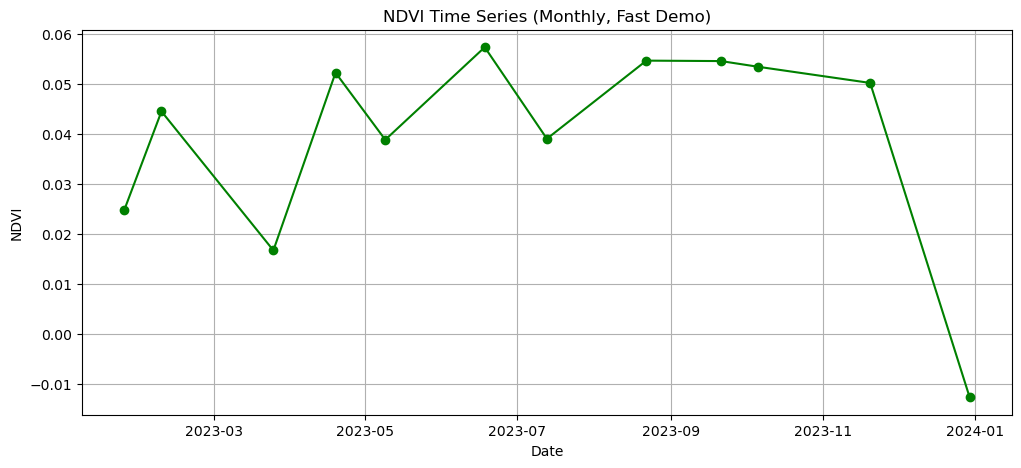

In [54]:
### Plot NDVI Time Series

plt.figure(figsize=(12,5))
plt.plot(df["date"], df["ndvi"], marker="o", color="green")
plt.title("NDVI Time Series (Monthly, Fast Demo)")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.grid(True)
plt.show()

In [66]:
### Plot the NVDI map for a given month

idx = 0  # pick a month index
item = items_monthly[idx]
signed = pc.sign(item)

red = rioxarray.open_rasterio(signed.assets["B05"].href, masked=True, chunks=True).squeeze()
nir = rioxarray.open_rasterio(signed.assets["B8A"].href, masked=True, chunks=True).squeeze()

stack = xr.Dataset({"red": red, "nir": nir})
stack_c = stack.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)
stack_c = stack_c.coarsen(x=2, y=2, boundary="trim").mean()

scale = 0.0001
red_s = stack_c["red"].astype("float32") * scale
nir_s = stack_c["nir"].astype("float32") * scale

ndvi_map = compute_ndvi(red_s, nir_s)

plt.figure(figsize=(8,6))
ndvi_map.plot(cmap="RdYlGn", vmin=-1, vmax=1)
plt.title(f"NDVI on {item.datetime.date()}")
plt.show()

KeyboardInterrupt: 

<Figure size 800x600 with 0 Axes>